# Modelado predictivo y evaluación de modelos - Bike Sharing

## Importación de librerías y dependencias
Este bloque inicial carga todas las herramientas necesarias para el proyecto, organizadas según su función: manipulación de datos, preprocesamiento, modelado, evaluación y persistencia.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

from pathlib import Path
import joblib

## Carga y exploración inicial del conjunto de datos
Establecemos la ruta base del proyecto, importamos los datos previamente limpios y realizamos una separación inicial entre las variables predictoras ($X$) y la variable objetivo ($y$), correspondiente al número total de bicicletas alquiladas (`cnt`). Posteriormente, inspeccionamos las dimensiones del dataset.

In [2]:
# Configuración de la ruta base y lectura del archivo CSV
BASE_DIR = Path().resolve().parent

df = pd.read_csv(BASE_DIR / "data" / "bike_clean.csv")

In [3]:
# Separación de características (X) y la variable objetivo (y)
X = df.drop(columns="cnt")
y = df["cnt"]

# Impresión de metadatos del conjunto de datos
print(f"Número de observaciones: {len(df)}")
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Variable objetivo: {y.name}")

# Visualización de las primeras filas
display(X.head())
display(y.head().to_frame())

Número de observaciones: 17379
Número de variables predictoras: 12
Variable objetivo: cnt


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


,cnt
0,16
1,40
2,32
3,13
4,1


## División del dataset y definición de tipos de variables
Para garantizar una evaluación objetiva, dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%). Adicionalmente, clasificamos de forma explícita las columnas en categóricas y numéricas para su posterior procesamiento.

In [4]:
# División del dataset en entrenamiento (Train) y prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
# Control de dimensiones resultantes
print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (13903, 12)
Test:  (3476, 12)


In [6]:
# Clasificación de características para el preprocesamiento
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

## Configuración del preprocesamiento y modelos lineales
Creamos un transformador de columnas (ColumnTransformer) para estandarizar las variables numéricas y aplicar codificación One-Hot a las categóricas. Luego, ensamblamos los pipelines para tres modelos basados en regresión lineal: Regresión Lineal Estándar, Ridge y Lasso.

In [7]:
# Configuración del preprocesador de datos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
# Pipeline 1: Regresión Lineal Múltiple
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [9]:
# Pipeline 2: Regresión Ridge (Regularización L2)
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [10]:
# Pipeline 3: Regresión Lasso (Regularización L1)
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

## Configuración de modelos no lineales y avanzados
Definimos los pipelines para modelos basados en árboles de decisión y ensambles (Gradient Boosting), configurando hiperparámetros iniciales para mitigar el riesgo de sobreajuste.

In [11]:
# Pipeline 4: Árbol de Decisión Regresor
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=10,
            random_state=42
        )
    )
])

In [12]:
# Pipeline 5: XGBoost Regresor
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    )
])

## Función genérica de evaluación de modelos
Diseñamos una función automatizada que entrena el pipeline suministrado, realiza predicciones tanto en el set de entrenamiento como en el de validación, y calcula métricas clave de rendimiento (MSE, MAE, R²) junto con una estimación del Overfitting.

In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Ajuste/Entrenamiento del modelo
    model.fit(X_train, y_train)
    
    # Predicciones de entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Cálculo de métricas de rendimiento en test
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    # Análisis de sobreajuste (Diferencia de R² entre train y test)
    train_r2 = r2_score(y_train, y_train_pred)

    return {
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Overfitting": train_r2 - r2
    }

## Ejecución del entrenamiento comparativo 
Agrupamos todos los pipelines en un diccionario y ejecutamos un ciclo iterativo para evaluar cada modelo de forma secuencial, almacenando los resultados obtenidos.

In [14]:
# Definición del diccionario de modelos a competir
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}
results = {}

# Iteración y evaluación masiva
for name, model in models.items():

    results[name] = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

## Visualización y análisis de los resultados
Convertimos el diccionario de resultados en un DataFrame de Pandas para su visualización tabular y generamos un gráfico de barras comparativo enfocado en el coeficiente de determinación ($R^2$).

In [15]:
# Transposición y construcción de la tabla de resultados
results_df = pd.DataFrame(results).T

results_df

,MSE,MAE,R2,Overfitting
Linear,10089.382718,74.105138,0.681375,0.005772
Ridge,10085.373318,74.092235,0.681502,0.005640
Lasso,10074.871746,73.935423,0.681834,0.004913
Decision Tree,9021.523800,68.793650,0.715098,0.028425
XGBoost,2191.255615,30.896545,0.930800,0.024726


Los modelos lineales (Linear, Ridge y Lasso) presentan un comportamiento muy similar, con valores de R² cercanos a 0.68 y un nivel de overfitting prácticamente nulo, lo que indica una buena capacidad de generalización, aunque con una precisión limitada para capturar relaciones complejas entre las variables.

El modelo Decision Tree mejora ligeramente el rendimiento predictivo, alcanzando un R² de 0.72 y reduciendo los errores (MSE y MAE). Sin embargo, muestra un incremento en el overfitting respecto a los modelos lineales.

XGBoost obtiene los mejores resultados en todas las métricas evaluadas, con un R² de 0.93 y una reducción muy significativa del error. Aunque presenta un nivel de overfitting superior al de los modelos lineales, la diferencia entre entrenamiento y prueba sigue siendo moderada, lo que indica una buena capacidad de generalización.

En conjunto, XGBoost se selecciona como modelo final al ofrecer el mejor equilibrio entre precisión predictiva y capacidad de generalización.

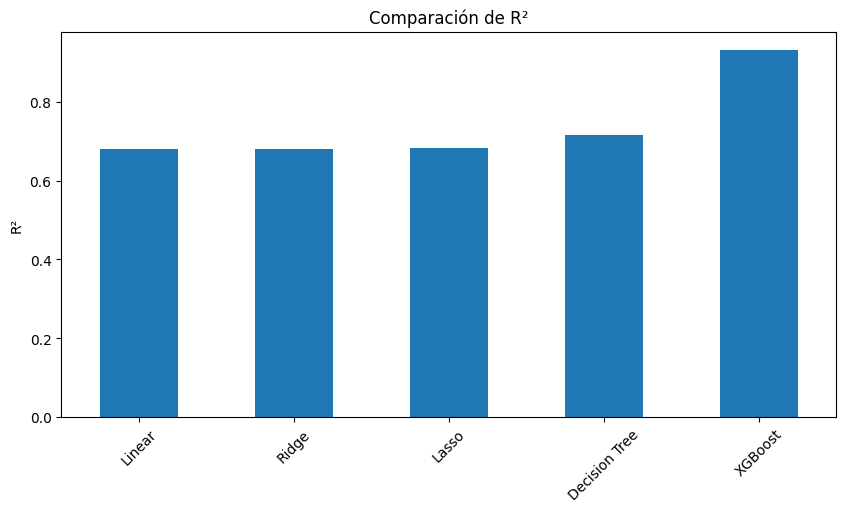

In [16]:
# Graficación del coeficiente R² por cada modelo
results_df["R2"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de R²")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra que los modelos lineales presentan un rendimiento similar, con valores de R² cercanos a 0.68. El árbol de decisión mejora ligeramente la capacidad predictiva, mientras que XGBoost destaca claramente sobre el resto, explicando aproximadamente el 93% de la variabilidad de la demanda de bicicletas.

## Validación cruzada robusta
Configuramos una validación cruzada de 5 pliegues para evaluar el rendimiento de cada modelo utilizando la métrica $R^2$.

In [17]:
# Configuración del esquema K-Fold para una validación cruzada robusta
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print(
        f"{name}: "
        f"{scores.mean():.3f} "
        f"(±{scores.std():.3f})"
    )

Linear: 0.684 (±0.008)
Ridge: 0.684 (±0.008)
Lasso: 0.684 (±0.008)
Decision Tree: 0.710 (±0.020)
XGBoost: 0.930 (±0.003)


Los resultados confirman la tendencia observada durante la evaluación inicial. Los modelos lineales (Linear, Ridge y Lasso) muestran un rendimiento muy similar, con un R² medio cercano a 0.68 y una variabilidad reducida entre particiones.

Decision Tree mejora la capacidad predictiva hasta un R² de 0.71, aunque presenta una mayor variación entre folds, lo que indica una menor estabilidad.

XGBoost obtiene nuevamente el mejor resultado, con un R² medio de 0.93 y una desviación estándar muy baja, demostrando una elevada precisión y un comportamiento consistente en las distintas particiones de los datos.

## Extracción y agrupación de la importancia de las variables
En esta sección se extraen los coeficientes o importancias de cada modelo, se recuperan los nombres originales de las variables transformadas por el preprocessor y se agrupan aquellas que fueron divididas por el One-Hot Encoding (OHE).

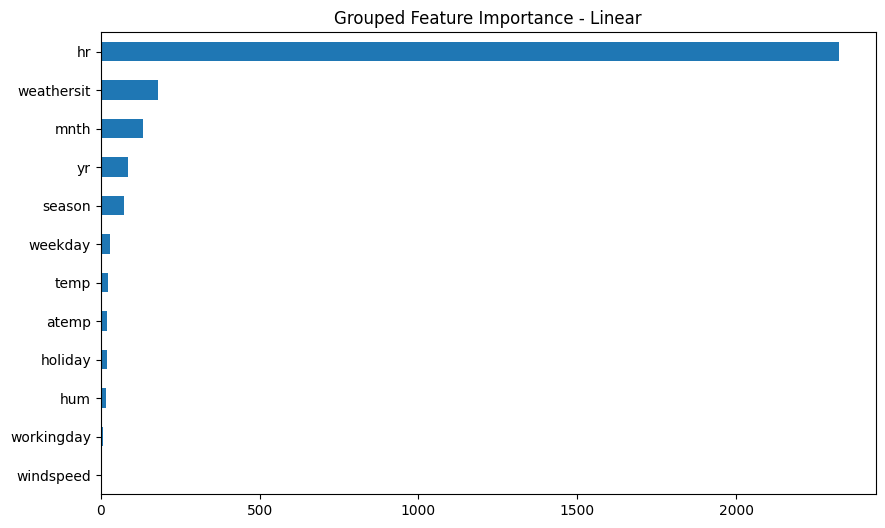

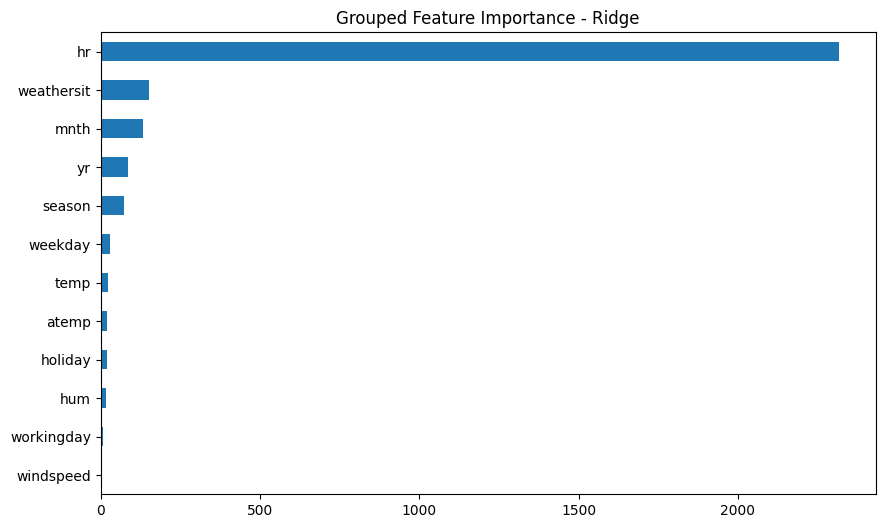

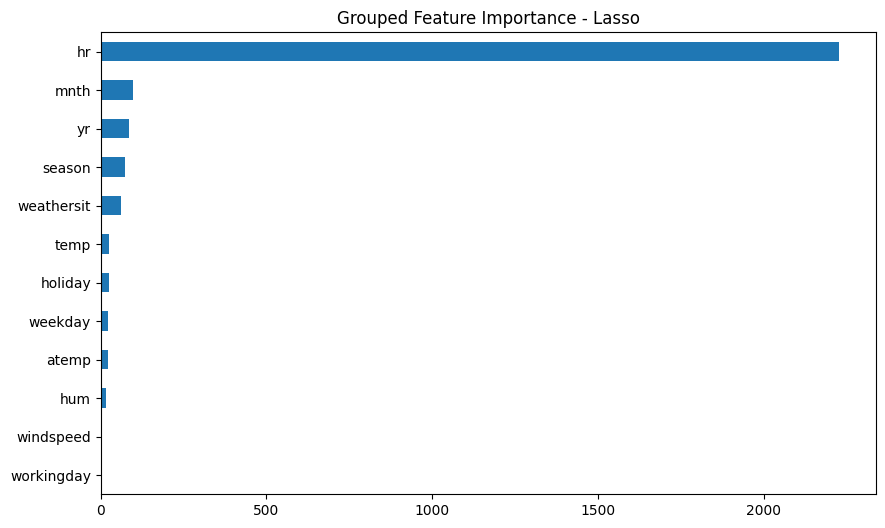

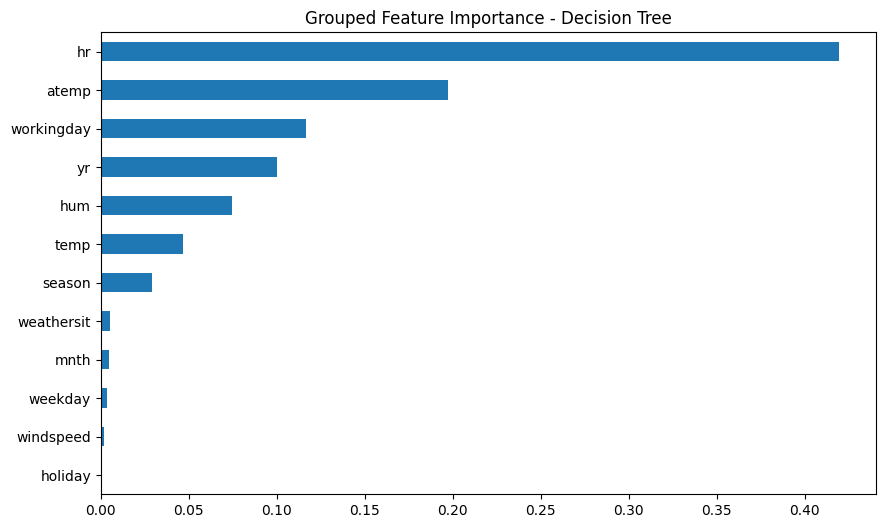

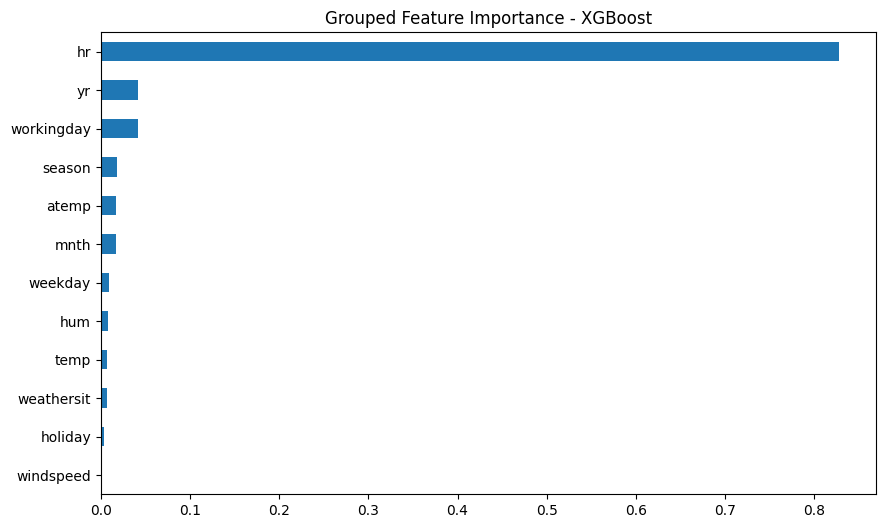

In [19]:
# Mapeo y nomenclatura de los pipelines creados
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

all_importances = {}

for name, model in models.items():
    # Extraer el estimador final del pipeline
    estimator = model.named_steps["model"]

    # Obtención de la importancia/coeficientes según el tipo de modelo
    if hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_)
    else:
        importance = estimator.feature_importances_

    # Recuperación de los nombres de las variables (features)
    ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = list(numeric_features) + list(cat_names)
    
    # Crear Serie de pandas con las importancias mapeadas a sus nombres
    fi = pd.Series(importance, index=feature_names)

    # Agrupación de variables derivadas (ej. 'Color_Rojo' -> 'Color')
    grouped = {}

    for feature, value in fi.items():
        base = feature.split("_")[0]
        grouped[base] = grouped.get(base, 0) + value

    # Ordenar los valores calculados de menor a mayor
    grouped = pd.Series(grouped).sort_values(ascending=True)

    all_importances[name] = grouped

    # Generación de Gráficos 
    plt.figure(figsize=(10,6))
    # Se grafican únicamente las 15 variables más importantes
    grouped.tail(15).plot(kind="barh")
    plt.title(f"Grouped Feature Importance - {name}")
    plt.show()

En todos los modelos, la variable **hora (`hr`)** aparece como el factor más influyente en la predicción de la demanda, lo que refleja los patrones de movilidad asociados a horarios laborales y actividades diarias.

Los modelos lineales (Linear, Ridge y Lasso) muestran una distribución similar de importancia, otorgando un peso elevado a la hora y una contribución menor a variables temporales y meteorológicas como `weathersit`, `mnth`, `yr`, `season` o `weekday`.

En Decision Tree y XGBoost, además de la hora, adquieren relevancia variables relacionadas con la estacionalidad (`yr`, `season`, `mnth`), el contexto laboral (`workingday`) y las condiciones meteorológicas (`atemp`, `hum`). Esto sugiere que los modelos basados en árboles capturan mejor relaciones no lineales y patrones más complejos presentes en los datos.

En conjunto, los resultados indican que la demanda de bicicletas está fuertemente condicionada por el momento temporal en el que se realiza la predicción, mientras que los factores climáticos y estacionales actúan como variables complementarias.

## Análisis y diagnóstico de residuos
Este script genera las predicciones para cada modelo y evalúa la calidad del ajuste mediante el **análisis visual de los residuos** ($e = y_{test} - y_{pred}$). Para cada modelo se generan dos gráficos críticos: la distribución de los errores y el gráfico de dispersión de residuos frente a predicciones.


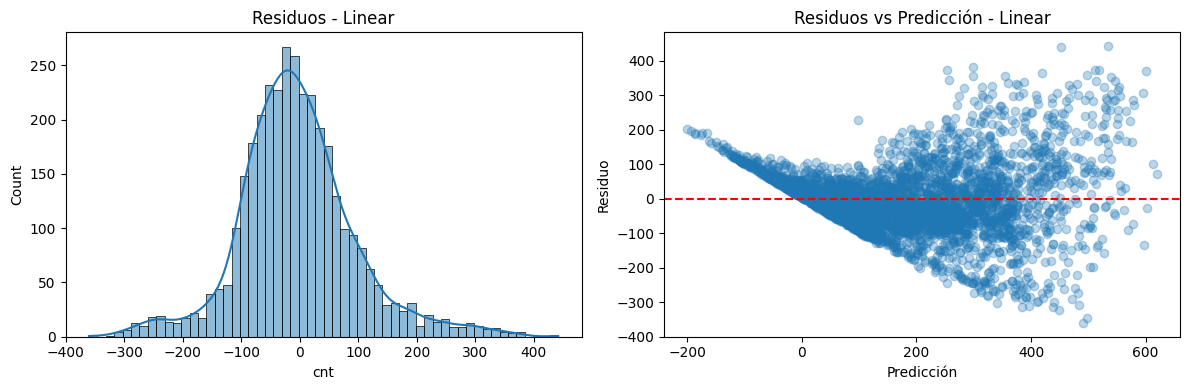

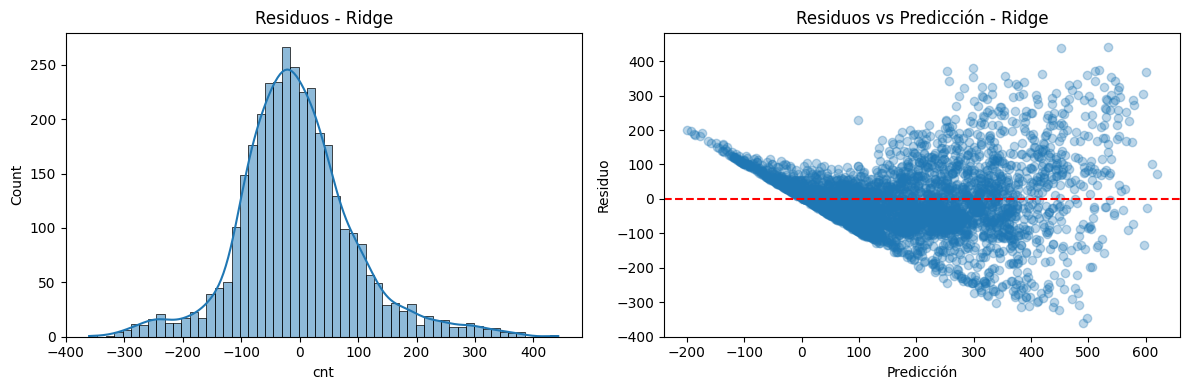

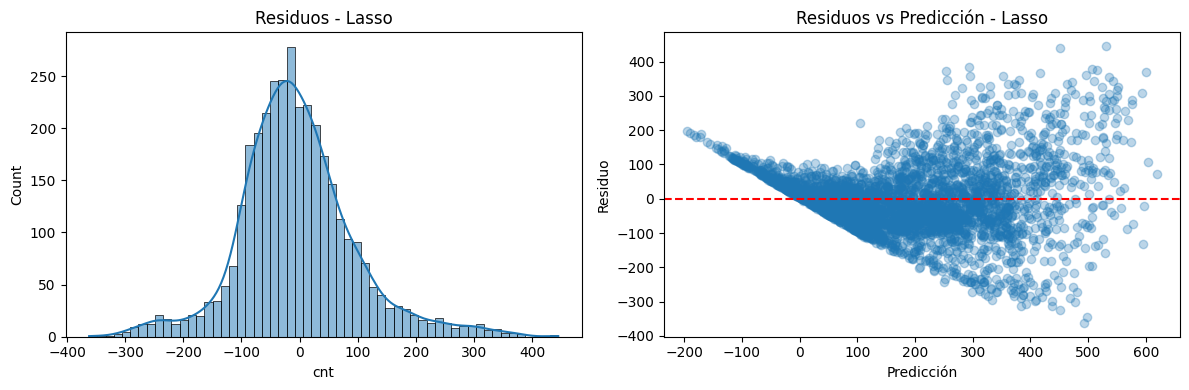

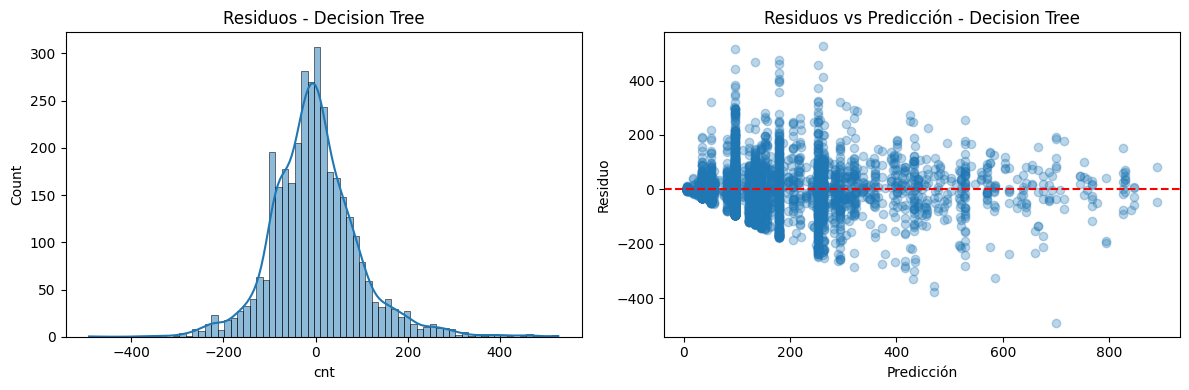

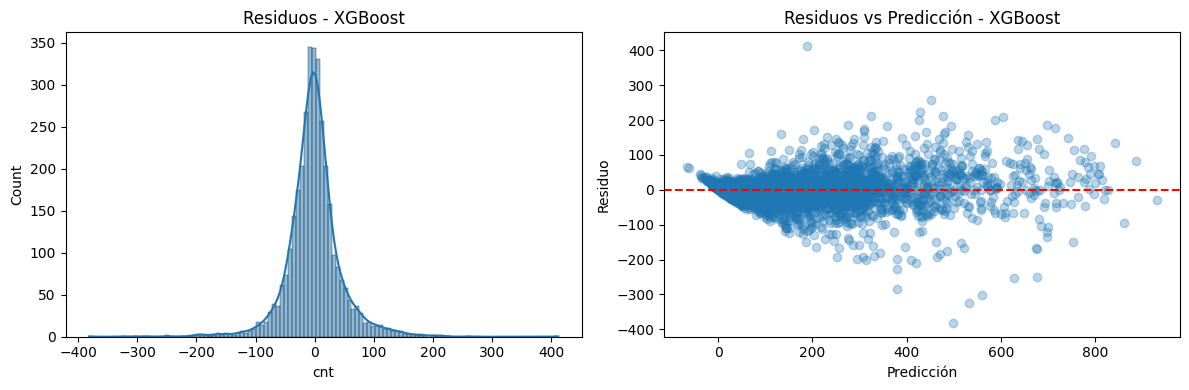

In [20]:
# Mapeo y nomenclatura de los pipelines evaluados
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

# Diccionario para almacenar los residuos de cada modelo
residuals_dict = {}

for name, model in models.items():

    # Generar predicciones en el set de prueba
    y_pred = model.predict(X_test)

    # Calcular residuos (Valor Real - Valor Predicho)
    residuals = y_test - y_pred
    residuals_dict[name] = residuals

    # Inicializar el lienzo del gráfico (1 fila, 2 columnas)
    plt.figure(figsize=(12,4))

    # Distribución de los residuos. Permite evaluar si los errores siguen una distribución normal (media cero)
    plt.subplot(1,2,1)
    sns.histplot(residuals, kde=True)
    plt.title(f"Residuos - {name}")

    # Residuos vs predicción. Permite identificar problemas de homocedasticidad o patrones no lineales
    plt.subplot(1,2,2)
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuos vs Predicción - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Residuo")
    
    # Ajustar elementos y mostrar gráficas del modelo actual
    plt.tight_layout()
    plt.show()

Los modelos lineales (Linear, Ridge y Lasso) presentan distribuciones de residuos centradas en cero, aunque con una dispersión relativamente amplia. En los gráficos de residuos frente a predicciones se observa una forma de embudo, lo que sugiere que el error aumenta para determinados rangos de predicción y que los modelos tienen dificultades para capturar toda la complejidad de los datos.

Decision Tree muestra una distribución de residuos más concentrada alrededor de cero y con colas menos pronunciadas. Sin embargo, en el gráfico de residuos aparecen patrones verticales característicos de los modelos basados en árboles, indicando predicciones discretizadas y una menor suavidad en las estimaciones.

XGBoost presenta la distribución de residuos más estrecha y concentrada en torno a cero, reflejando errores generalmente más pequeños. Además, los residuos se distribuyen de forma más homogénea alrededor de la línea horizontal de referencia, sin patrones evidentes, lo que sugiere un mejor ajuste y una mayor capacidad para modelar las relaciones presentes en los datos.

In [21]:
# Cálculo Rápido del Error Medio Absoluto (MAE)
for name, res in residuals_dict.items():
    print(name, np.mean(np.abs(res)))

Linear 74.10513821067401
Ridge 74.09223510415589
Lasso 73.93542319058237
Decision Tree 68.7936502851899
XGBoost 30.896546365804134


El Error Medio Absoluto (MAE) confirma la misma tendencia observada en las métricas anteriores. Los modelos lineales presentan errores similares, en torno a 74 bicicletas, lo que indica una precisión moderada pero limitada.

Decision Tree mejora el rendimiento reduciendo el error medio a aproximadamente 69 bicicletas, aunque sigue siendo menos preciso que los modelos más avanzados.

XGBoost obtiene el mejor resultado con un MAE de aproximadamente 31 bicicletas, lo que refleja una reducción significativa del error y un mejor ajuste global del modelo a los datos.

## Gráficos de dispersión: valores reales vs. predicciones
Esta sección compara visualmente el valor real (y_test) frente al predicho (y_pred). La línea diagonal roja discontinua ($y = x$) representa el "modelo perfecto"; cuanto más cerca estén los puntos de esta línea, mejor es la predicción.

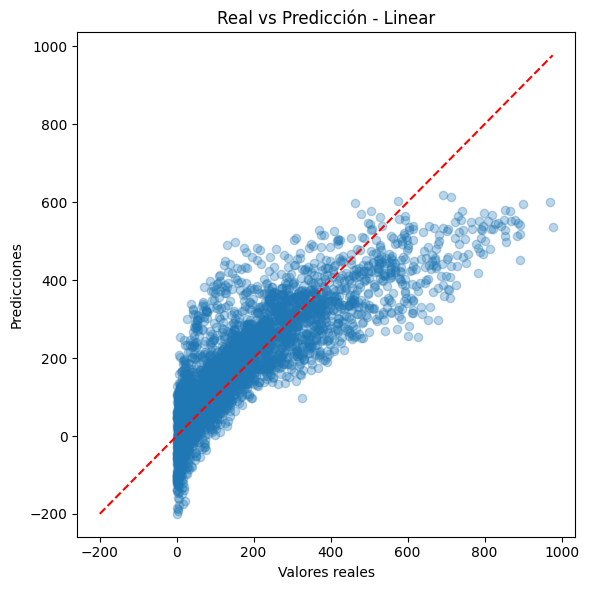

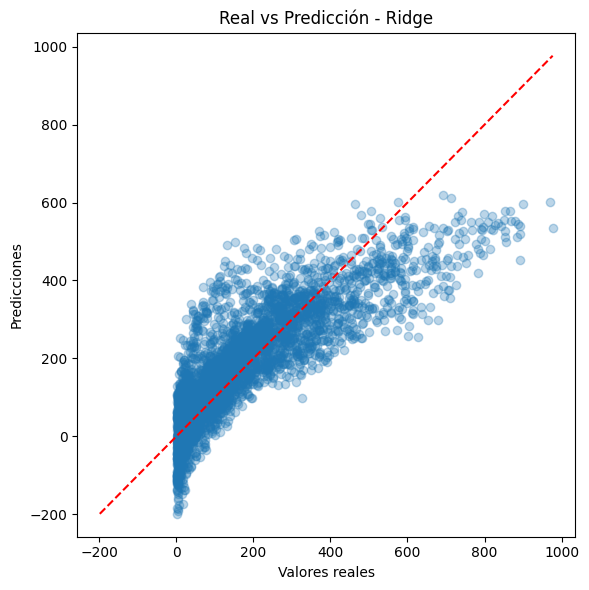

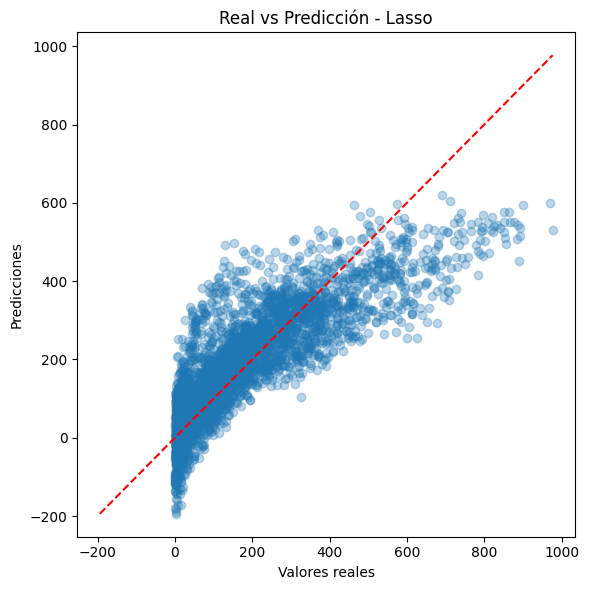

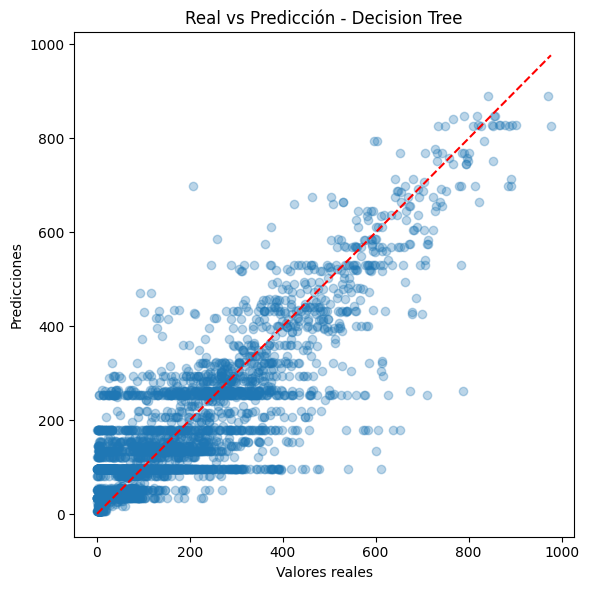

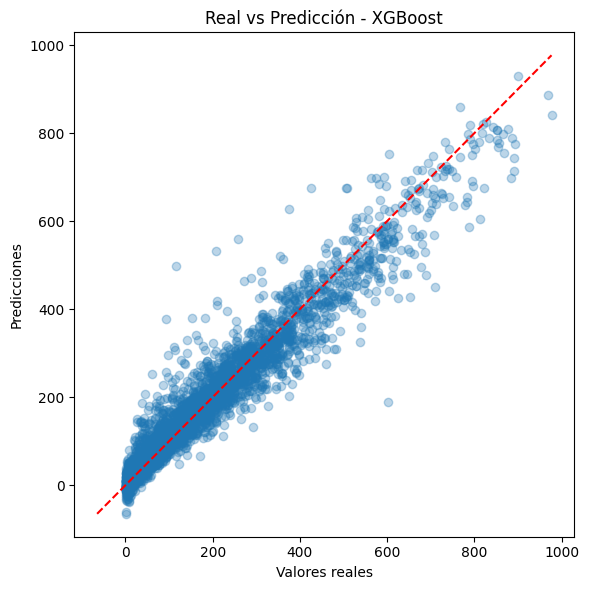

In [22]:
# Diccionario con los nombres y pipelines para la evaluación gráfica
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():

    # Generar predicciones
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,6))

    plt.scatter(y_test, y_pred, alpha=0.3)

    # Definir los límites dinámicos para trazar una línea perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

    # Configuración de etiquetas y títulos
    plt.title(f"Real vs Predicción - {name}")
    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")

    plt.tight_layout()
    plt.show()

En los modelos lineales (Linear, Ridge y Lasso) se observa una mayor dispersión de los puntos respecto a la línea ideal (y = x), especialmente en los valores más altos. Aunque existe una tendencia general alineada con la diagonal, el modelo tiende a cometer errores más visibles a medida que aumenta la demanda, reflejando una menor capacidad para capturar relaciones complejas.

Decision Tree muestra un comportamiento más estructurado, con predicciones agrupadas en niveles discretos, lo que genera patrones en forma de “escalones”. Los puntos se aproximan a la diagonal en la zona central, aunque con cierta dispersión en los extremos.

XGBoost presenta el mejor ajuste visual, con puntos mucho más concentrados alrededor de la línea de referencia. La predicción sigue de forma más fiel los valores reales, especialmente en el rango medio, aunque aparecen pequeñas desviaciones en valores extremos.

En conjunto, los gráficos confirman nuevamente que XGBoost es el modelo con mejor capacidad predictiva y mayor fidelidad respecto a los valores reales.

## Persistencia y guardado de modelos (serialización)
Para finalizar, se crea una carpeta física llamada models (en caso de que no exista) y se guardan los pipelines utilizando la librería joblib con nombres en minúsculas (buenas prácticas para nombres de archivos).

In [23]:
# carpeta models
models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)
# Diccionario con nomenclatura adaptada para nombres de archivos (.pkl)
models = {
    "linear": linear_pipeline,
    "ridge": ridge_pipeline,
    "lasso": lasso_pipeline,
    "decision_tree": tree_pipeline,
    "xgboost": xgb_pipeline
}
# Bucle para serializar y exportar cada modelo
for name, model in models.items():
    path = models_dir / f"{name}_model.pkl"
    joblib.dump(model, path)
    print(f"Modelo guardado: {name} -> {path}")

Modelo guardado: linear -> C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\linear_model.pkl
Modelo guardado: ridge -> C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\ridge_model.pkl
Modelo guardado: lasso -> C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\lasso_model.pkl
Modelo guardado: decision_tree -> C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\decision_tree_model.pkl
Modelo guardado: xgboost -> C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-Project-Regression-Grupo1\models\xgboost_model.pkl
